In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, accuracy_score,
    precision_score, recall_score, f1_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import statistics
from sklearn import metrics
import matplotlib.pyplot as plt
import math

In [59]:
def compute_metrics(y_true, y_pred, label=""):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    return {
        "Set": label,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    }

In [52]:
def remove_outliers_iqr(df, features):
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[feature] >= Q1 - 1.5 * IQR) & (df[feature] <= Q3 + 1.5 * IQR)]
    return df

In [54]:
from ucimlrepo import fetch_ucirepo 

breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 
  
df_breast = breast_cancer_wisconsin_original.data.features 
df_breast ['target'] = breast_cancer_wisconsin_original.data.targets

df_breast['Bare_nuclei']=df_breast['Bare_nuclei'].fillna(df_breast['Bare_nuclei'].median())
#df_breast = remove_outliers_iqr(df_breast, ['Clump_thickness', 'Uniformity_of_cell_size','Uniformity_of_cell_shape','Marginal_adhesion','Single_epithelial_cell_size','Bare_nuclei','Bland_chromatin','Normal_nucleoli','Mitoses'])
df_breast['target'] = df_breast['target'].replace({4: 1, 2: 0})

X_train, X_test = train_test_split(df_breast, test_size=0.2, random_state=2, stratify=df_breast['target'])

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=df_breast.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=df_breast.columns)
X_train = X_train_scaled.iloc[:, :-1]
X_test = X_test_scaled.iloc[:, :-1]
y_train = X_train_scaled.iloc[:, -1]
y_test = X_test_scaled.iloc[:, -1]

In [69]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Naive Bayes": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", GaussianNB())
        ]),
        "params": {
            "clf__var_smoothing": np.logspace(-5, 5)
        }
    },

    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", LogisticRegression(random_state=2))
        ]),
        "params": {
            "clf__C": [0.1, 1]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", RandomForestClassifier(random_state=2))
        ]),
        "params": {
            "clf__n_estimators": [50, 500],
            "clf__max_depth": [2, 10]
        }
    },

    "Neural Network": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", MLPClassifier(max_iter=500, random_state=2))
        ]),
        "params": {
            "clf__hidden_layer_sizes": [(10,), (20,), (50,), (10,10), (50,50)],
            "clf__activation": ["relu", "tanh"],
            "clf__solver": ['adam', 'sgd']
        }
    }
}

In [70]:
all_results = []

for name, config in models.items():
    print(f"\n{'='*60}")
    print(f"  Model: {name}")
    print(f"{'='*60}")

    gs = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    print(f"  The best params : {gs.best_params_}")
    print(f"  CV F1 (val. set)   : {gs.best_score_:.4f}")

    y_train_pred = cross_val_predict(best_model, X_train, y_train, cv=cv)
    train_metrics = compute_metrics(y_train, y_train_pred, label="Train (CV)")

    y_test_pred = best_model.predict(X_test)
    test_metrics = compute_metrics(y_test, y_test_pred, label="Test")

    for m in [train_metrics, test_metrics]:
        print(f"\n  [{m['Set']}]")
        for k, v in m.items():
            if k != "Set":
                print(f"    {k:<12}: {v}")

    all_results.append({"Model": name, **train_metrics})
    all_results.append({"Model": name, **test_metrics})


  Model: Naive Bayes
  The best params : {'clf__var_smoothing': 0.07543120063354623}
  CV F1 (val. set)   : 0.9661

  [Train (CV)]
    MSE         : 0.034
    RMSE        : 0.1844
    Accuracy    : 0.966
    Precision   : 0.9307
    Recall      : 0.9741
    F1          : 0.9519

  [Test]
    MSE         : 0.0286
    RMSE        : 0.169
    Accuracy    : 0.9714
    Precision   : 0.9783
    Recall      : 0.9375
    F1          : 0.9574

  Model: Logistic Regression
  The best params : {'clf__C': 1}
  CV F1 (val. set)   : 0.9625

  [Train (CV)]
    MSE         : 0.0376
    RMSE        : 0.1938
    Accuracy    : 0.9624
    Precision   : 0.9479
    Recall      : 0.943
    F1          : 0.9455

  [Test]
    MSE         : 0.0357
    RMSE        : 0.189
    Accuracy    : 0.9643
    Precision   : 1.0
    Recall      : 0.8958
    F1          : 0.9451

  Model: Random Forest
  The best params : {'clf__max_depth': 2, 'clf__n_estimators': 50}
  CV F1 (val. set)   : 0.9661

  [Train (CV)]
    MSE  

In [71]:
print(f"\n\n{'='*60}")
print("Metrics")
print(f"{'='*60}")
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index(["Model", "Set"])
print(df_results.to_string())



Metrics
                                   MSE    RMSE  Accuracy  Precision  Recall      F1
Model               Set                                                            
Naive Bayes         Train (CV)  0.0340  0.1844    0.9660     0.9307  0.9741  0.9519
                    Test        0.0286  0.1690    0.9714     0.9783  0.9375  0.9574
Logistic Regression Train (CV)  0.0376  0.1938    0.9624     0.9479  0.9430  0.9455
                    Test        0.0357  0.1890    0.9643     1.0000  0.8958  0.9451
Random Forest       Train (CV)  0.0340  0.1844    0.9660     0.9350  0.9689  0.9517
                    Test        0.0357  0.1890    0.9643     0.9778  0.9167  0.9462
Neural Network      Train (CV)  0.0322  0.1794    0.9678     0.9442  0.9637  0.9538
                    Test        0.0429  0.2070    0.9571     0.9773  0.8958  0.9348


In [75]:
def yes_function(x, y, a, kappa, lam, gamma=1):
    return 1 - np.maximum(0.0, ((1-x)**kappa + (1-y)**kappa - (1-a)**kappa))**(1/kappa)

def no_function(x, y, a, kappa, lam, gamma=1):
    return np.maximum(0.0, (x**lam + y**lam - a**lam))**(1/lam)

def maybe_function(x, y, a, kappa, lam, gamma=1):
    if x is None or y is None:
        return 0
    if gamma == 0:
        return 0
    a = np.clip(a, 1e-6, 1 - 1e-6)
    x = np.clip(x, 0, 1)
    y = np.clip(y, 0, 1)
    value = gamma*(1/a)*x*y + (1-gamma)*(1 - (1/(1-a))*(1-x)*(1-y))
    return statistics.median([0, 1, value])

def classification(x, y, a, kappa, lam, gamma):
    if x < a and y < a:
        return no_function(x, y, a, 1, lam, 1)
    elif x > a and y > a:
        return yes_function(x, y, a, kappa, 1, 1)
    else:
        return maybe_function(x, y, a, 1, 1, gamma)

def classification_vec(values, diffs, a, kappa, lam, gamma):
    if values.size == 0 or diffs.size == 0:
        return np.zeros_like(values)

    results = np.zeros_like(values, dtype=float)
    mask_no    = (values < a) & (diffs < a)
    mask_yes   = (values > a) & (diffs > a)
    mask_maybe = ~(mask_no | mask_yes)

    if np.any(mask_no):
        results[mask_no] = no_function(values[mask_no], diffs[mask_no], a, 1, lam, 1)
    if np.any(mask_yes):
        results[mask_yes] = yes_function(values[mask_yes], diffs[mask_yes], a, kappa, 1, 1)
    if np.any(mask_maybe):
        for idx in np.where(mask_maybe)[0]:
            results[idx] = maybe_function(values[idx], diffs[idx], a, 1, 1, gamma)

    return np.round(results, 4)

In [77]:
def show_results(data, mean_error, gamma_result, lam_result, kappa_result, a_result):
    target_values = data[['target']].values
    value = data[['calc_value']].values
    MSE = mean_squared_error(target_values, value)
    RMSE = math.sqrt(MSE)
    print('Results:')
    if all(col in data.columns for col in ['value','error']):
      print(data.drop(columns=['value','error']))
    else:
      print(data)
    print('\u03B3 = ', round(gamma_result, 4))
    print('\u03BB = ', round(lam_result, 4))
    print('\u03BA = ', round(kappa_result, 4))
    print('a = ', round(a_result, 4))
    print('Mean squared error = ', round(MSE, 4))
    print('Root Mean Square Error = ', round(RMSE, 4))

In [79]:
def calculate_tests(target_values, value):
  print('Accuracy score = ', accuracy_score(target_values, value))
  print('F1 = ', f1_score(target_values, value, average='macro'))
  print('Precision = ', precision_score(target_values, value, average='macro'))
  print('Recall = ', recall_score(target_values, value, average='macro'))
  confusion_matrix = metrics.confusion_matrix(target_values, value)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
  cm_display.plot()
  plt.show()

Accuracy score =  0.6636851520572451
F1 =  0.42307861220904697
Precision =  0.5129533678756477
Recall =  0.8303249097472925


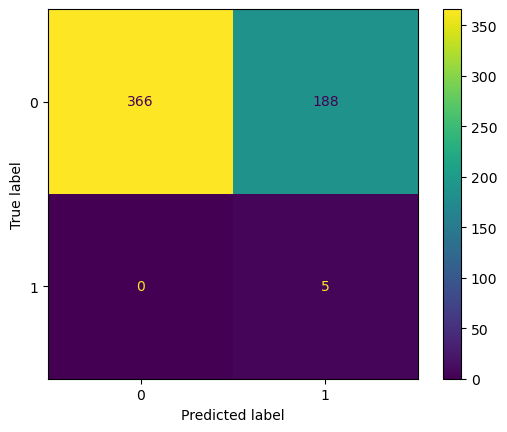

In [188]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.95, 2.3, 2.3, 0.5), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= 0.95)else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= 0.95)else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

In [190]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.95, 2.3, 2.3, 0.5), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)

Results:
     Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
0           0.444444                 0.000000                  0.000000   
1           1.000000                 0.777778                  0.777778   
2           0.333333                 0.000000                  0.000000   
3           0.000000                 0.000000                  0.000000   
4           0.555556                 0.000000                  0.222222   
..               ...                      ...                       ...   
135         0.333333                 0.000000                  0.000000   
136         0.444444                 0.000000                  0.000000   
137         0.333333                 0.000000                  0.000000   
138         0.333333                 0.000000                  0.111111   
139         0.333333                 0.000000                  0.000000   

     Marginal_adhesion  Single_epithelial_cell_size  Bare_nuclei  \
0             0.111111

In [192]:
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<0.95)else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']< 0.95)else 1, axis=1)

In [194]:
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values

Accuracy score =  0.6571428571428571
F1 =  0.39655172413793105
Precision =  0.32857142857142857
Recall =  0.5


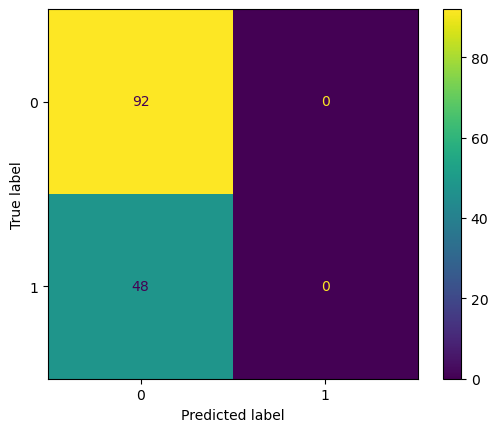

In [196]:
calculate_tests(target_values, value)

In [85]:
import numpy as np
import statistics
import itertools
from tqdm import tqdm

def error_metric(values, labels, a, kappa, lam, gamma):
    columns = len(X_test_scaled.columns)
    X_test_scaled['calc_value'] = X_test_scaled.apply(lambda row: row[0], axis=1)
    j = 0
    while j < columns - 2:
        X_test_scaled['calc_value'] = X_test_scaled.apply(
            lambda row: classification(row['calc_value'], row[j+1], a, kappa, lam, gamma), axis=1
        )
        j += 1
    return np.mean(np.abs(X_test_scaled['calc_value'] - labels))

def randomized_grid_search(values, labels, n_iter=2000, random_state=42):
    np.random.seed(random_state)

    a_range     = np.round(np.arange(0.05, 1, 0.05), 2)
    gamma_range = np.round(np.arange(0.05, 1, 0.05), 2)
    kappa_range = np.round(np.arange(0.05, 3, 0.05), 2)
    lam_range   = np.round(np.arange(0.05, 3, 0.05), 2)

    all_combos = list(itertools.product(a_range, kappa_range, lam_range, gamma_range))
    n_iter = min(n_iter, len(all_combos))
    sampled = [all_combos[i] for i in np.random.choice(len(all_combos), size=n_iter, replace=False)]

    best_params = None
    best_error  = np.inf
    results     = []

    #print(f"Ukupno kombinacija: {len(all_combos)}")
    #print(f"Nasumično uzorkovano: {n_iter}")

    for a, kappa, lam, gamma in tqdm(sampled):
        if kappa == 0 or lam == 0:
            continue
        try:
            error = error_metric(values, labels, a, kappa, lam, gamma)
        except Exception:
            continue

        results.append({
            "a": a, "kappa": kappa, "lam": lam, "gamma": gamma,
            "error": error
        })

        if error < best_error:
            best_error  = error
            best_params = {"a": a, "kappa": kappa, "lam": lam, "gamma": gamma}

    print("\nBest params:")
    print(f"  a     = {best_params['a']}")
    print(f"  kappa = {best_params['kappa']}")
    print(f"  lam   = {best_params['lam']}")
    print(f"  gamma = {best_params['gamma']}")
    print(f"  greška (MAE) = {best_error:.6f}")

    return best_params, best_error, results

if __name__ == "__main__":
    values = X_train
    labels = y_train
    best_params, best_error, all_results = randomized_grid_search(values, labels, n_iter=2000)

100%|██████████| 2000/2000 [15:09<00:00,  2.20it/s]


Best params:
  a     = 0.95
  kappa = 2.25
  lam   = 2.5
  gamma = 0.95
  greška (MAE) = 0.357857


Accuracy score =  0.6547406082289803
F1 =  0.3956756756756757
Precision =  0.5
Recall =  0.32737030411449014


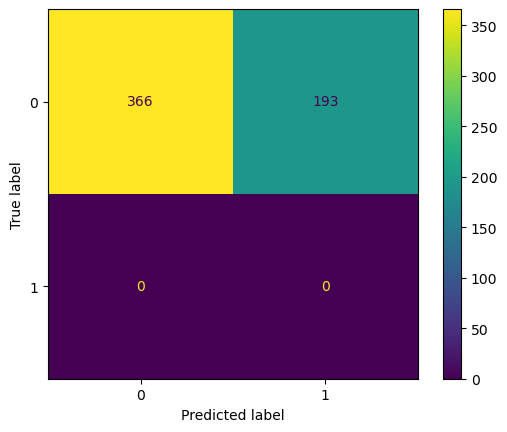

In [87]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.95, 2.25, 2.5, 0.95), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= 0.95)else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= 0.95)else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

Results:
     Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
0           0.444444                 0.000000                  0.000000   
1           1.000000                 0.777778                  0.777778   
2           0.333333                 0.000000                  0.000000   
3           0.000000                 0.000000                  0.000000   
4           0.555556                 0.000000                  0.222222   
..               ...                      ...                       ...   
135         0.333333                 0.000000                  0.000000   
136         0.444444                 0.000000                  0.000000   
137         0.333333                 0.000000                  0.000000   
138         0.333333                 0.000000                  0.111111   
139         0.333333                 0.000000                  0.000000   

     Marginal_adhesion  Single_epithelial_cell_size  Bare_nuclei  \
0             0.111111

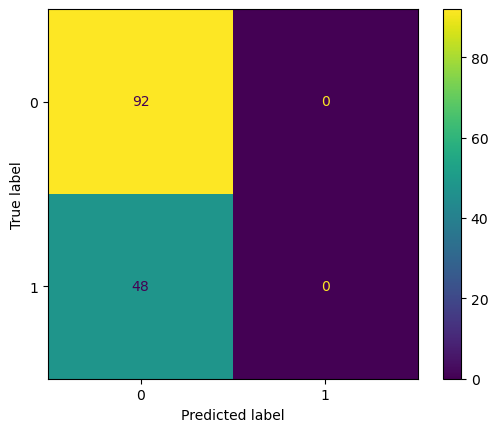

In [89]:
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], 0.95, 2.25, 2.5, 0.95), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<0.95)else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']< 0.95)else 1, axis=1)
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values
calculate_tests(target_values, value)